# Imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import pandas as pd

from PIL import Image
from tqdm.auto import tqdm

import torch

from transformers import (
    CLIPModel,
    CLIPProcessor
)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Config

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CHECKPOINT = "/content/drive/MyDrive/Surgical-VLM/checkpoints/best_openclip"

processor = CLIPProcessor.from_pretrained(CHECKPOINT)

model = CLIPModel.from_pretrained(CHECKPOINT)

model = model.to(DEVICE)

model.eval()

print("Model loaded.")

# FIX: load the SAME matched, per-task-capped test set that
# 8_FineTuneVisionLLM.ipynb also evaluates on (built in 4b_MatchedSubset.ipynb),
# instead of loading the full openclip_dataset.pkl and re-deriving a
# train/val/test split here with train_test_split(). That re-derivation
# produced a DIFFERENT test set than the one saved in 4_OpenCLIPDataset.ipynb
# whenever random_state or dataset size changed, and wasn't matched to what
# the VLM notebook evaluates on either.



Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Model loaded.


In [ ]:
import json
from pathlib import Path

CONFIG = Path("/content/drive/MyDrive/Surgical-VLM/configs/config.json")
with open(CONFIG) as f:
    config = json.load(f)
PROCESSED_DIR = Path(config["processed_dir"])

matched_test = pd.read_parquet(PROCESSED_DIR / "matched_test.parquet").reset_index(drop=True)

print(matched_test.shape)
matched_test.head()

print(matched_test["gt_label"].isna().sum(), "rows failed to match")  # should be 0

matched_test[matched_test.task.isin(["Instrument Recognition", "Phase Recognition"])][
    ["task", "question", "answer", "gt_label"]
].head(10)

for t in ["Phase Recognition", "Triplet Recognition", "Action Recognition",
          "Safety Assessment", "Tissue and Organ Recognition", "Surgical Image Captioning"]:
    print(f"--- {t} ---")
    print(matched_test[matched_test.task == t][["question", "answer", "gt_label"]].head(3))
    print()

(5600, 18)
800 rows failed to match
--- Phase Recognition ---
                                               question  \
1600  Given the laparoscopic cholecystectomy image, ...   
1601  Given the laparoscopic cholecystectomy image, ...   
1602  Given the laparoscopic cholecystectomy image, ...   

                         answer                       gt_label  
1600  Calot Triangle Dissection  ["Calot Triangle Dissection"]  
1601                Preparation                ["Preparation"]  
1602  Calot Triangle Dissection  ["Calot Triangle Dissection"]  

--- Triplet Recognition ---
                                               question  \
4800  You are a helpful assistant! Please generate t...   
4801  Given the laparoscopic cholecystectomy image, ...   
4802  What is the instrument doing to the target in ...   

                                                 answer  \
4800  {"answers": "C. grasper B. retract H. gallblad...   
4801  grasper retract gallbladder, hook dissect gall...  

In [ ]:
matched_test[matched_test.task == "Instrument Localization"][
    ["question", "answer", "gt_label"]
].head(5)

,question,answer,gt_label


# load fine-tuned model

In [ ]:
from transformers import CLIPModel, CLIPProcessor

MODEL_DIR = CHECKPOINT

processor = CLIPProcessor.from_pretrained(MODEL_DIR)

model = CLIPModel.from_pretrained(MODEL_DIR)

model.to(DEVICE)
model.eval()

print("Model loaded successfully!")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Model loaded successfully!


In [ ]:
print(type(model))

<class 'transformers.models.clip.modeling_clip.CLIPModel'>


In [ ]:
row = matched_test.iloc[0]

image = Image.open(row["image_full_path"]).convert("RGB")

inputs = processor(
    images=image,
    text=str(row["answer"]),
    return_tensors="pt",
    padding=True
)

inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

vision_outputs = model.vision_model(pixel_values=inputs["pixel_values"])
image_features = model.visual_projection(vision_outputs.pooler_output)

print(image_features.shape)

torch.Size([1, 512])


# Img and Text embeddings

In [ ]:
from pathlib import Path
from PIL import Image
import numpy as np
import torch
from tqdm.auto import tqdm

image_embeddings = []
text_embeddings = []
valid_indices = []

successful = 0
failed = 0

model.eval()

with torch.no_grad():

    for idx, row in tqdm(matched_test.iterrows(), total=len(matched_test)):

        try:

            # -----------------------------
            # Load image
            # -----------------------------
            image_path = Path(row["image_full_path"])

            if not image_path.exists():
                failed += 1
                continue

            image = Image.open(image_path).convert("RGB")

            caption = str(row["answer"])

            # -----------------------------
            # Processor
            # -----------------------------
            inputs = processor(
                images=image,
                text=caption,
                return_tensors="pt",
                padding=True,
                truncation=True
            )

            inputs = {
                k: v.to(DEVICE)
                for k, v in inputs.items()
            }

            # ==========================================================
            # IMAGE EMBEDDING
            # ==========================================================

            vision_outputs = model.vision_model(
                pixel_values=inputs["pixel_values"]
            )

            image_features = model.visual_projection(
                vision_outputs.pooler_output
            )

            # ==========================================================
            # TEXT EMBEDDING
            # ==========================================================

            text_outputs = model.text_model(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"]
            )

            text_features = model.text_projection(
                text_outputs.pooler_output
            )

            # ==========================================================
            # NORMALIZE
            # ==========================================================

            image_features = torch.nn.functional.normalize(
                image_features,
                dim=-1
            )

            text_features = torch.nn.functional.normalize(
                text_features,
                dim=-1
            )

            image_embeddings.append(
                image_features.cpu().numpy().squeeze()
            )

            text_embeddings.append(
                text_features.cpu().numpy().squeeze()
            )

            valid_indices.append(idx)

            successful += 1

        except Exception as e:

            failed += 1
            print(f"Row {idx} failed: {e}")

image_embeddings = np.stack(image_embeddings)
text_embeddings = np.stack(text_embeddings)

evaluation_df = (
    matched_test
    .iloc[valid_indices]
    .reset_index(drop=True)
)

print("=" * 60)
print(f"Successful samples : {successful}")
print(f"Failed samples     : {failed}")
print(f"Image embeddings   : {image_embeddings.shape}")
print(f"Text embeddings    : {text_embeddings.shape}")
print(f"Evaluation samples : {len(evaluation_df)}")
print("=" * 60)

  0%|          | 0/5600 [00:00<?, ?it/s]

Successful samples : 5600
Failed samples     : 0
Image embeddings   : (5600, 512)
Text embeddings    : (5600, 512)
Evaluation samples : 5600


# Save Embeddings

In [ ]:
RESULTS_DIR = Path("/content/drive/MyDrive/Surgical-VLM/results")

np.save(
    RESULTS_DIR / "image_embeddings.npy",
    image_embeddings
)

np.save(
    RESULTS_DIR / "text_embeddings.npy",
    text_embeddings
)

evaluation_df.to_parquet(
    RESULTS_DIR / "evaluation_df.parquet",
    index=False
)

print("Embeddings saved.")

Embeddings saved.


In [ ]:
print(evaluation_df.columns.tolist())
evaluation_df["task_group"].value_counts()

['sample_id', 'image_id', 'case_id', 'image_path', 'image_full_path', 'image_exists', 'source_dataset', 'specialty', 'surgery_type', 'question', 'thinking', 'answer', 'task', 'task_group', 'gt_label', 'annotator', 'text', 'label_set']


,count
task_group,
Understanding and Reasoning,5600


In [ ]:
!pip install umap-learn -q

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


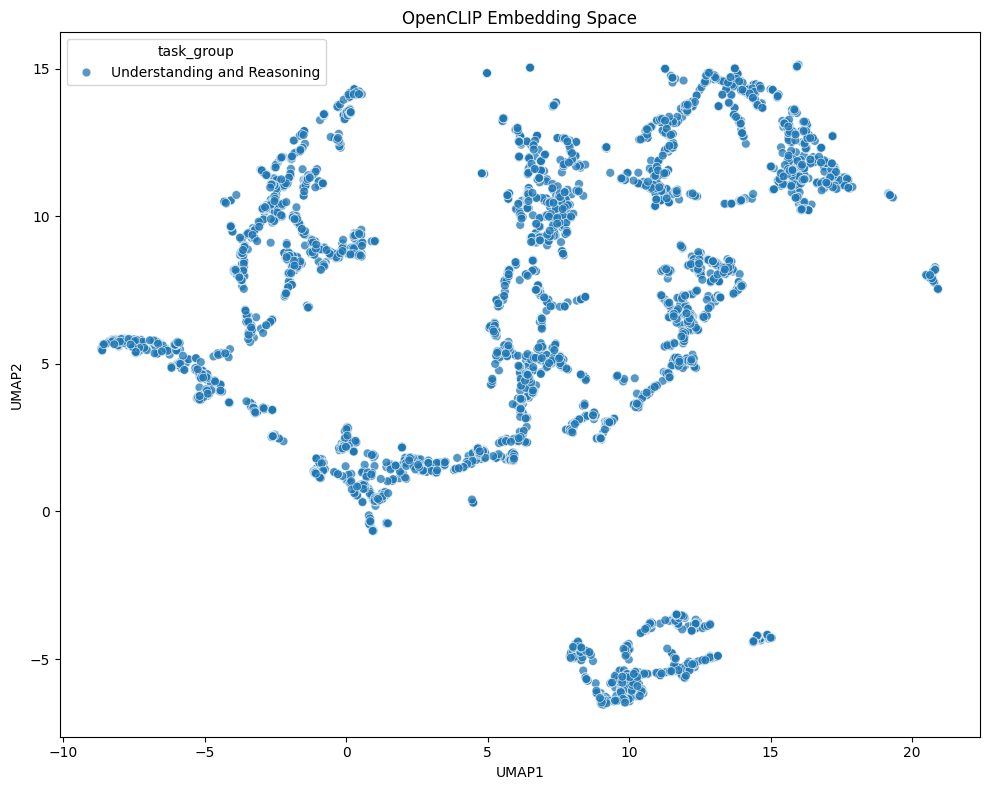

In [ ]:
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

embedding_2d = reducer.fit_transform(image_embeddings)

plot_df = evaluation_df.copy()
plot_df["UMAP1"] = embedding_2d[:, 0]
plot_df["UMAP2"] = embedding_2d[:, 1]

plt.figure(figsize=(10,8))

sns.scatterplot(
    data=plot_df,
    x="UMAP1",
    y="UMAP2",
    hue="task_group",
    alpha=0.75,
    s=40
)

plt.title("OpenCLIP Embedding Space")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "umap_embeddings.png", dpi=300)
plt.show()

### Diagnostic: Task-Identity Separability (not the RQ metric)

This logistic-regression probe tests whether image embeddings cluster separably by *task* — it does **not** measure whether the model correctly matched an image to its correct answer. It's a useful sanity check on embedding quality, but the metric that's actually comparable to the VLM's per-task exact-match/BLEU (from `9_evaluateVLLM.ipynb`) is the **retrieval accuracy** computed further down this notebook.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report
)

X = image_embeddings
y = evaluation_df["task"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

classifier = LogisticRegression(
    max_iter=5000,
    random_state=42
)

classifier.fit(X_train, y_train)

predictions = classifier.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    predictions,
    average="weighted"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, predictions))

Accuracy : 0.2179
Precision: 0.2144
Recall   : 0.2179
F1-score : 0.2017

Classification Report

                              precision    recall  f1-score   support

          Action Recognition       0.21      0.09      0.12       160
      Instrument Recognition       0.15      0.06      0.08       160
           Phase Recognition       0.23      0.23      0.23       160
           Safety Assessment       0.28      0.16      0.20       160
   Surgical Image Captioning       0.22      0.41      0.28       160
Tissue and Organ Recognition       0.22      0.31      0.26       160
         Triplet Recognition       0.20      0.27      0.23       160

                    accuracy                           0.22      1120
                   macro avg       0.21      0.22      0.20      1120
                weighted avg       0.21      0.22      0.20      1120



In [ ]:
# Save the classification report to a text file
report_str = classification_report(y_test, predictions)
with open(RESULTS_DIR / "classification_report.txt", "w") as f:
    f.write(report_str)
print(f"Classification report saved to {RESULTS_DIR}/classification_report.txt")

Classification report saved to /content/drive/MyDrive/Surgical-VLM/results/classification_report.txt


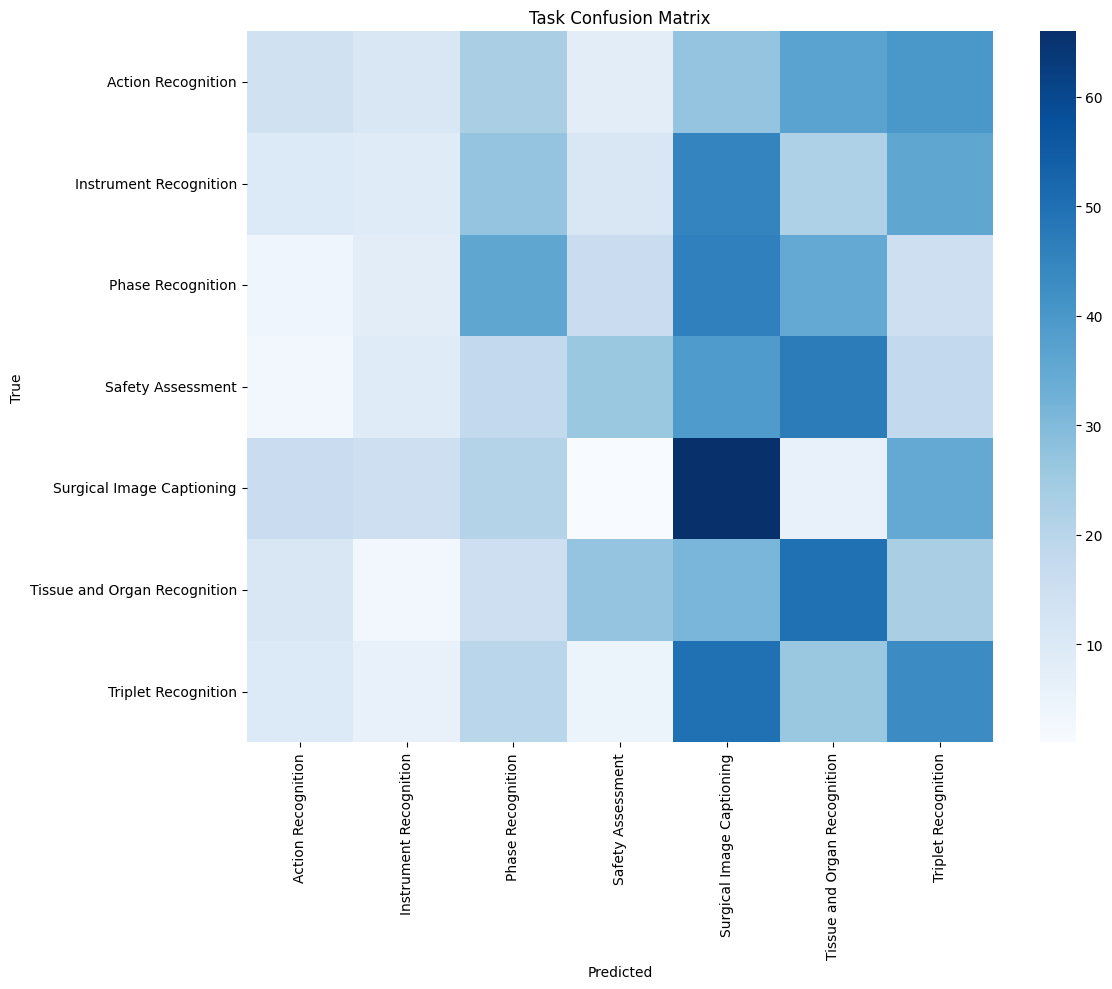

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    predictions,
    labels=classifier.classes_
)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=classifier.classes_,
    yticklabels=classifier.classes_
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Task Confusion Matrix")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrix.png", dpi=300)
plt.show()

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

paired_similarity = cosine_similarity(
    image_embeddings,
    text_embeddings
)

scores = paired_similarity.diagonal()

print(f"Mean similarity  : {scores.mean():.4f}")
print(f"Median similarity: {np.median(scores):.4f}")
print(f"Std deviation    : {scores.std():.4f}")

Mean similarity  : 0.2141
Median similarity: 0.2216
Std deviation    : 0.0266


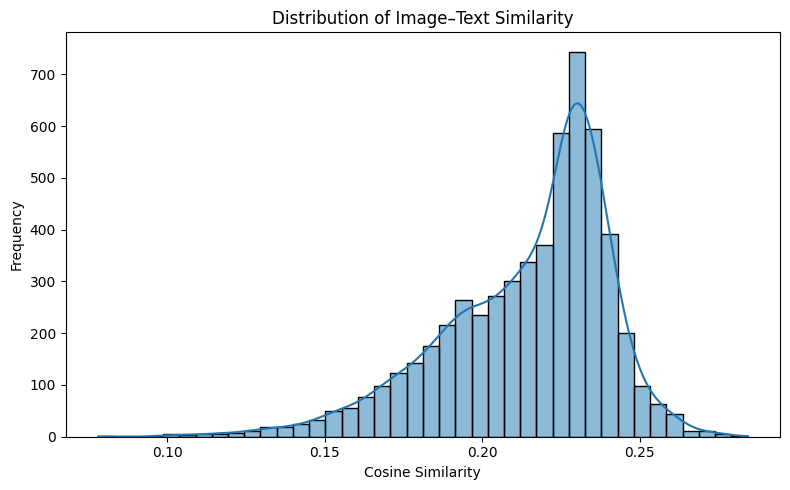

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    scores,
    bins=40,
    kde=True
)

plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")
plt.title("Distribution of Image–Text Similarity")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "cosine_similarity_distribution.png", dpi=300)
plt.show()

In [ ]:
results = pd.DataFrame({

    "Metric":[
        "Task-Identity Probe Accuracy",
        "Task-Identity Probe Precision",
        "Task-Identity Probe Recall",
        "Task-Identity Probe F1",
        "Mean Cosine Similarity",
        "Median Cosine Similarity"
    ],

    "Value":[
        accuracy,
        precision,
        recall,
        f1,
        scores.mean(),
        np.median(scores)
    ]

})

results

,Metric,Value
0,Task-Identity Probe Accuracy,0.217857
1,Task-Identity Probe Precision,0.214443
2,Task-Identity Probe Recall,0.217857
3,Task-Identity Probe F1,0.201713
4,Mean Cosine Similarity,0.214140
5,Median Cosine Similarity,0.221620


### Save Results and Figures

In [ ]:
# Save the main results DataFrame
results.to_csv(RESULTS_DIR / "overall_metrics.csv", index=False)
print("Overall metrics saved to overall_metrics.csv")

Overall metrics saved to overall_metrics.csv


# Per-Task Retrieval Accuracy (Top-1)


,task,n_samples,n_candidates,top1_retrieval_accuracy
3,Safety Assessment,800,7,0.68125
5,Tissue and Organ Recognition,800,19,0.54375
2,Phase Recognition,800,102,0.39250
1,Instrument Recognition,800,263,0.27250
0,Action Recognition,800,259,0.21625
6,Triplet Recognition,800,300,0.12875
4,Surgical Image Captioning,800,775,0.01750


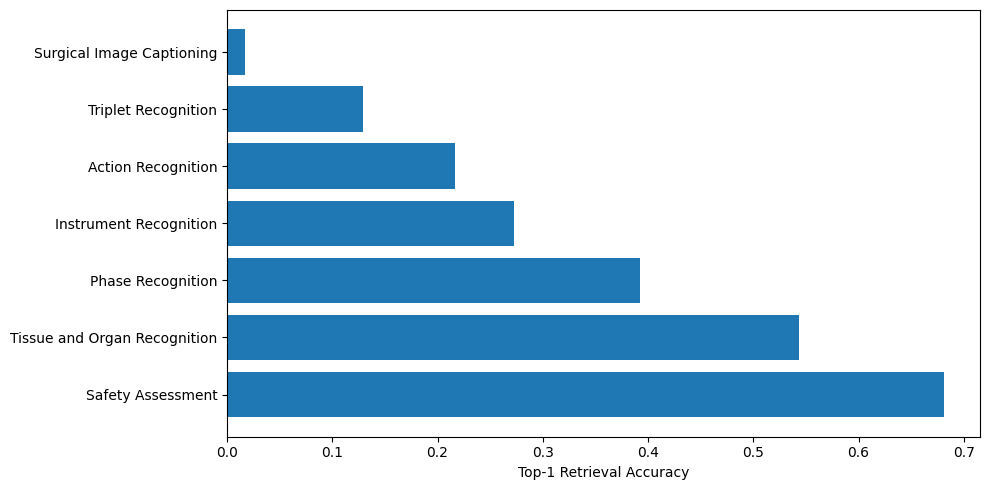

In [ ]:
import numpy as np

task_metrics_rows = []

for task_name, task_group in evaluation_df.groupby("task"):

    # Candidate answers: the unique set of ground-truth answers seen for
    # this task in the (matched) test set.
    candidate_answers = sorted(task_group["answer"].astype(str).unique())

    if len(candidate_answers) < 2:
        # Retrieval accuracy is undefined/trivial with <2 candidates
        task_metrics_rows.append({
            "task": task_name,
            "n_samples": len(task_group),
            "n_candidates": len(candidate_answers),
            "top1_retrieval_accuracy": np.nan
        })
        continue

    # Embed all candidate answers for this task once
    with torch.no_grad():
        cand_inputs = processor(
            text=candidate_answers,
            return_tensors="pt",
            padding=True,
            truncation=True
        )
        cand_inputs = {k: v.to(DEVICE) for k, v in cand_inputs.items()}

        cand_text_outputs = model.text_model(
            input_ids=cand_inputs["input_ids"],
            attention_mask=cand_inputs["attention_mask"]
        )
        cand_features = model.text_projection(cand_text_outputs.pooler_output)
        cand_features = torch.nn.functional.normalize(cand_features, dim=-1)
        cand_features = cand_features.cpu().numpy()

    # Pull this task's rows' image embeddings (already computed above) and
    # their ground-truth answer index within candidate_answers
    task_mask = evaluation_df["task"] == task_name
    task_image_embeddings = image_embeddings[task_mask.values]
    gt_answers = task_group["answer"].astype(str).values

    # Cosine similarity between each image and every candidate answer
    sims = task_image_embeddings @ cand_features.T
    pred_idx = sims.argmax(axis=1)
    pred_answers = np.array(candidate_answers)[pred_idx]

    correct = (pred_answers == gt_answers).sum()
    accuracy = correct / len(gt_answers)

    task_metrics_rows.append({
        "task": task_name,
        "n_samples": len(task_group),
        "n_candidates": len(candidate_answers),
        "top1_retrieval_accuracy": accuracy
    })

task_metrics_df = pd.DataFrame(task_metrics_rows).sort_values(
    "top1_retrieval_accuracy", ascending=False
)

display(task_metrics_df)

plt.figure(figsize=(10, 5))
plt.barh(task_metrics_df["task"], task_metrics_df["top1_retrieval_accuracy"])
plt.xlabel("Top-1 Retrieval Accuracy")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "retrieval_accuracy_per_task.png", dpi=300)
plt.show()


In [ ]:
# Save the task-specific metrics DataFrame
task_metrics_df.to_csv(RESULTS_DIR / "task_specific_metrics.csv", index=False)
print("Task-specific metrics saved to task_specific_metrics.csv")

Task-specific metrics saved to task_specific_metrics.csv


In [ ]:
# ============================================================
# LOAD SAVED OPENCLIP EVALUATION DATA
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

RESULTS_DIR = Path("/content/drive/MyDrive/Surgical-VLM/results/OpenCLIP Results")

image_embeddings = np.load(
    RESULTS_DIR / "image_embeddings.npy"
)

text_embeddings = np.load(
    RESULTS_DIR / "text_embeddings.npy"
)

evaluation_df = pd.read_parquet(
    RESULTS_DIR / "evaluation_df.parquet"
)

print("Image embeddings:", image_embeddings.shape)
print("Text embeddings :", text_embeddings.shape)
print("Evaluation rows :", len(evaluation_df))
print("\nColumns:")
print(evaluation_df.columns.tolist())

Image embeddings: (5600, 512)
Text embeddings : (5600, 512)
Evaluation rows : 5600

Columns:
['sample_id', 'image_id', 'case_id', 'image_path', 'image_full_path', 'image_exists', 'source_dataset', 'specialty', 'surgery_type', 'question', 'thinking', 'answer', 'task', 'task_group', 'gt_label', 'annotator', 'text', 'label_set']


In [ ]:
# ============================================================
# INSPECT TASKS AND ANSWERS
# ============================================================

print("TASKS:")
print(evaluation_df["task"].value_counts())

for task in evaluation_df["task"].dropna().unique():

    print("\n" + "=" * 70)
    print(task)
    print("=" * 70)

    subset = evaluation_df[
        evaluation_df["task"] == task
    ]

    print("Number of rows:", len(subset))
    print("Unique answers:", subset["answer"].nunique())

    print("\nExample answers:")
    for answer in subset["answer"].dropna().astype(str).unique()[:20]:
        print(" -", answer)

TASKS:
task
Action Recognition              800
Instrument Recognition          800
Phase Recognition               800
Safety Assessment               800
Surgical Image Captioning       800
Tissue and Organ Recognition    800
Triplet Recognition             800
Name: count, dtype: int64

Action Recognition
Number of rows: 800
Unique answers: 259

Example answers:
 - The grasper is performing a retract action in this surgery image.
 - retract, dissect
 - The grasper is performing a retract action in this surgical scene.
 - dissect
 - The bipolar is involved in performing coagulate within this procedure.
 - The hook completes a dissect task in this surgical image.
 - The grasper performs a retract action during this surgical procedure.
 - The grasper is assigned the task of retract in this surgical image.
 - The grasper is accomplishing a retract task in this surgery.
 - The hook is engaged in dissect during this surgery.
 - The movement carried out by the grasper is retract in this su

In [ ]:
# ============================================================
# CANONICAL CHOLEC T50 LABELS
# ============================================================

CANONICAL_POOLS = {

    "Instrument Recognition": [
        "grasper",
        "bipolar",
        "hook",
        "scissors",
        "clipper",
        "irrigator",
    ],

    "Action Recognition": [
        "grasp",
        "retract",
        "dissect",
        "coagulate",
        "clip",
        "cut",
        "aspirate",
        "irrigate",
        "pack",
        "null_verb",
    ],

    "Tissue and Organ Recognition": [
        "gallbladder",
        "cystic_artery",
        "cystic artery",
        "cystic_duct",
        "cystic duct",
        "cystic_plate",
        "cystic plate",
        "liver",
        "specimen_bag",
        "specimen bag",
        "fluid",
        "abdominal_wall_cavity",
        "abdominal wall cavity",
        "omentum",
        "blood_vessel",
        "gut",
        "peritoneum",
        "cystic_pedicle",
        "adhesion",
        "null_target",

    ],


    "Phase Recognition": [
        "Preparation",
        "Calot Triangle Dissection",
        "Clipping Cutting",
        "Gallbladder Dissection",
        "Gallbladder Packaging",
        "Cleaning Coagulation",
        "Gallbladder Retraction",
    ],
}

for task, candidates in CANONICAL_POOLS.items():
    print(f"{task}: {len(candidates)} candidates")

Instrument Recognition: 6 candidates
Action Recognition: 10 candidates
Tissue and Organ Recognition: 20 candidates
Phase Recognition: 7 candidates


In [ ]:
import re


def extract_canonical_labels(text, candidates):
    """
    Extract canonical labels from a generated/raw answer.

    Returns a set so that repeated mentions do not inflate
    the ground-truth label set.
    """

    text = str(text).lower()

    found = set()

    for candidate in candidates:

        candidate_lower = candidate.lower()

        # Convert underscores to flexible whitespace
        pattern = re.escape(candidate_lower)
        pattern = pattern.replace(r"\_", r"[\s_]")

        if re.search(r"\b" + pattern + r"\b", text):
            found.add(candidate)

    # Handle the common "null target" representation
    if "null target" in text:
        if "null_target" in candidates:
            found.add("null_target")

    if "null verb" in text:
        if "null_verb" in candidates:
            found.add("null_verb")

    return found

In [ ]:
# ============================================================
# CREATE CANONICAL GROUND-TRUTH LABELS
# ============================================================

evaluation_df = evaluation_df.copy()

evaluation_df["canonical_labels"] = None

for task, candidates in CANONICAL_POOLS.items():

    mask = evaluation_df["task"] == task

    evaluation_df.loc[mask, "canonical_labels"] = (
        evaluation_df.loc[mask, "answer"]
        .apply(
            lambda x: sorted(
                extract_canonical_labels(
                    x,
                    candidates
                )
            )
        )
    )
for task in CANONICAL_POOLS:

    subset = evaluation_df[
        evaluation_df["task"] == task
    ]

    print("\n" + "=" * 70)
    print(task)
    print("=" * 70)

    for _, row in subset.head(10).iterrows():

        print("RAW:")
        print(row["answer"])

        print("CANONICAL:")
        print(row["canonical_labels"])

        print()


Instrument Recognition
RAW:
hook
CANONICAL:
['hook']

RAW:
bipolar
CANONICAL:
['bipolar']

RAW:
grasper
CANONICAL:
['grasper']

RAW:
## Surgical Answers
(1) They fit into Clipper.
(2) The identified phase is Clipping Cutting.
CANONICAL:
['clipper']

RAW:
## Surgical Answers
(1) They fall under the categories Grasper, Hook.
(2) The identified phase is Gallbladder Dissection.
CANONICAL:
['grasper', 'hook']

RAW:
grasper, hook
CANONICAL:
['grasper', 'hook']

RAW:
hook
CANONICAL:
['hook']

RAW:
They are classified into the categories: grasper, hook.
CANONICAL:
['grasper', 'hook']

RAW:
hook
CANONICAL:
['hook']

RAW:
hook
CANONICAL:
['hook']


Action Recognition
RAW:
The grasper is performing a retract action in this surgery image.
CANONICAL:
['retract']

RAW:
retract, dissect
CANONICAL:
['dissect', 'retract']

RAW:
The grasper is performing a retract action in this surgical scene.
CANONICAL:
['retract']

RAW:
retract, dissect
CANONICAL:
['dissect', 'retract']

RAW:
dissect
CANONICAL:
['di

In [ ]:
# ============================================================
# NORMALIZATION QUALITY CHECK
# ============================================================

for task in CANONICAL_POOLS:

    subset = evaluation_df[
        evaluation_df["task"] == task
    ]

    failures = subset[
        subset["canonical_labels"].apply(
            lambda x: len(x) == 0
        )
    ]

    print(
        f"{task:35s} "
        f"rows={len(subset):4d} "
        f"unparsed={len(failures):4d} "
        f"rate={len(failures)/len(subset):.2%}"
    )

Instrument Recognition              rows= 800 unparsed=   1 rate=0.12%
Action Recognition                  rows= 800 unparsed=   0 rate=0.00%
Tissue and Organ Recognition        rows= 800 unparsed=   0 rate=0.00%
Phase Recognition                   rows= 800 unparsed=   0 rate=0.00%


In [ ]:
# ============================================================
# ENCODE CANONICAL CANDIDATE LABELS
# ============================================================

import torch
import torch.nn.functional as F
import numpy as np


def encode_candidate_texts(candidates):

    inputs = processor(
        text=candidates,
        return_tensors="pt",
        padding=True,
        truncation=True
    )

    inputs = {
        k: v.to(DEVICE)
        for k, v in inputs.items()
    }

    with torch.no_grad():

        text_outputs = model.text_model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"]
        )

        features = model.text_projection(
            text_outputs.pooler_output
        )

        features = F.normalize(
            features,
            dim=-1
        )

    return features.cpu().numpy()

# ============================================================
# GENERATE CANDIDATE EMBEDDINGS
# ============================================================

candidate_embeddings = {}

for task, candidates in CANONICAL_POOLS.items():

    candidate_embeddings[task] = encode_candidate_texts(
        candidates
    )

    print(
        task,
        candidate_embeddings[task].shape
    )

Instrument Recognition (6, 512)
Action Recognition (10, 512)
Tissue and Organ Recognition (20, 512)
Phase Recognition (7, 512)


In [ ]:
# ============================================================
# WITHIN-TASK CANONICAL OPENCLIP RETRIEVAL
# ============================================================

retrieval_rows = []

single_label_tasks = {
    "Phase Recognition"
}

for task, candidates in CANONICAL_POOLS.items():

    task_mask = evaluation_df["task"].values == task
    task_indices = np.where(task_mask)[0]

    candidate_matrix = candidate_embeddings[task]

    similarities = (
        image_embeddings[task_indices]
        @ candidate_matrix.T
    )

    predicted_indices = similarities.argmax(axis=1)

    correct = 0
    total = 0

    for local_idx, predicted_idx in enumerate(predicted_indices):

        row_idx = task_indices[local_idx]

        true_labels = evaluation_df.iloc[row_idx]["canonical_labels"]

        if not true_labels:
            continue

        predicted_label = candidates[predicted_idx]

        # Single-label exact match
        if task in single_label_tasks:

            if len(true_labels) == 1:
                correct += (
                    predicted_label == true_labels[0]
                )
                total += 1

        else:
            # For now, top-1 counts as correct if the retrieved
            # canonical label is one of the ground-truth labels.
            correct += (
                predicted_label in true_labels
            )
            total += 1

    accuracy = correct / total if total else np.nan
    chance = 1 / len(candidates)

    retrieval_rows.append({
        "Task": task,
        "Candidate count": len(candidates),
        "N evaluated": total,
        "Top-1 accuracy": accuracy,
        "Chance": chance,
        "Lift over chance": accuracy - chance
    })

canonical_retrieval_df = pd.DataFrame(
    retrieval_rows
)

canonical_retrieval_df

,Task,Candidate count,N evaluated,Top-1 accuracy,Chance,Lift over chance
0,Instrument Recognition,6,799,0.909887,0.166667,0.743221
1,Action Recognition,10,800,0.571250,0.100000,0.471250
2,Tissue and Organ Recognition,20,800,0.638750,0.050000,0.588750
3,Phase Recognition,7,800,0.766250,0.142857,0.623393


In [ ]:
# ============================================================
# MULTI-LABEL OPENCLIP METRICS
# ============================================================

from sklearn.metrics import precision_score, recall_score, f1_score

multilabel_rows = []

for task in [
    "Instrument Recognition",
    "Action Recognition",
    "Tissue and Organ Recognition"
]:

    candidates = CANONICAL_POOLS[task]

    task_indices = np.where(
        evaluation_df["task"].values == task
    )[0]

    candidate_matrix = candidate_embeddings[task]

    similarities = (
        image_embeddings[task_indices]
        @ candidate_matrix.T
    )

    y_true = []
    y_pred = []

    exact_matches = 0

    for i, row_idx in enumerate(task_indices):

        true_labels = set(
            evaluation_df.iloc[row_idx]["canonical_labels"]
        )

        predicted_idx = similarities[i].argmax()

        predicted_label = candidates[predicted_idx]

        # OpenCLIP produces ONE top-ranked candidate
        predicted_labels = {predicted_label}

        true_vector = [
            int(candidate in true_labels)
            for candidate in candidates
        ]

        pred_vector = [
            int(candidate in predicted_labels)
            for candidate in candidates
        ]

        y_true.append(true_vector)
        y_pred.append(pred_vector)

        if true_labels == predicted_labels:
            exact_matches += 1

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    multilabel_rows.append({

        "Task": task,

        "N": len(task_indices),

        "Mean GT set size": y_true.sum(axis=1).mean(),

        "Exact set accuracy":
            exact_matches / len(task_indices),

        "Micro precision":
            precision_score(
                y_true,
                y_pred,
                average="micro",
                zero_division=0
            ),

        "Micro recall":
            recall_score(
                y_true,
                y_pred,
                average="micro",
                zero_division=0
            ),

        "Micro F1":
            f1_score(
                y_true,
                y_pred,
                average="micro",
                zero_division=0
            )
    })

openclip_multilabel_df = pd.DataFrame(
    multilabel_rows
)

openclip_multilabel_df

,Task,N,Mean GT set size,Exact set accuracy,Micro precision,Micro recall,Micro F1
0,Instrument Recognition,800,1.44625,0.49125,0.90875,0.628349,0.742974
1,Action Recognition,800,1.17375,0.43625,0.57125,0.486688,0.525589
2,Tissue and Organ Recognition,800,1.19625,0.49875,0.63875,0.533960,0.581673


In [ ]:
# ============================================================
# MAJORITY-CLASS BASELINES
# ============================================================

from collections import Counter

majority_rows = []

for task in CANONICAL_POOLS:

    subset = evaluation_df[
        evaluation_df["task"] == task
    ]

    # Count individual ground-truth labels
    label_counts = Counter()

    for labels in subset["canonical_labels"]:

        for label in labels:
            label_counts[label] += 1

    majority_label, majority_count = (
        label_counts.most_common(1)[0]
    )

    # Label-hit baseline
    total = len(subset)

    hit_count = sum(
        majority_label in labels
        for labels in subset["canonical_labels"]
    )

    majority_accuracy = hit_count / total

    majority_rows.append({
        "Task": task,
        "Majority label": majority_label,
        "Majority baseline": majority_accuracy,
        "N": total
    })

majority_baseline_df = pd.DataFrame(
    majority_rows
)

majority_baseline_df

,Task,Majority label,Majority baseline,N
0,Instrument Recognition,hook,0.69625,800
1,Action Recognition,dissect,0.50875,800
2,Tissue and Organ Recognition,gallbladder,0.82125,800
3,Phase Recognition,Gallbladder Dissection,0.39875,800


In [ ]:
# ============================================================
# FIXED-50 OPENCLIP EVALUATION
# ============================================================

import numpy as np
import pandas as pd

RANDOM_SEEDS = range(10)
N_CANDIDATES = 50

# Combine all canonical labels
ALL_CANONICAL_LABELS = []

for task, labels in CANONICAL_POOLS.items():
    for label in labels:
        if label not in ALL_CANONICAL_LABELS:
            ALL_CANONICAL_LABELS.append(label)

print("Total unique canonical labels:",
      len(ALL_CANONICAL_LABELS))

print(ALL_CANONICAL_LABELS)

Total unique canonical labels: 43
['grasper', 'bipolar', 'hook', 'scissors', 'clipper', 'irrigator', 'grasp', 'retract', 'dissect', 'coagulate', 'clip', 'cut', 'aspirate', 'irrigate', 'pack', 'null_verb', 'gallbladder', 'cystic_artery', 'cystic artery', 'cystic_duct', 'cystic duct', 'cystic_plate', 'cystic plate', 'liver', 'specimen_bag', 'specimen bag', 'fluid', 'abdominal_wall_cavity', 'abdominal wall cavity', 'omentum', 'blood_vessel', 'gut', 'peritoneum', 'cystic_pedicle', 'adhesion', 'null_target', 'Preparation', 'Calot Triangle Dissection', 'Clipping Cutting', 'Gallbladder Dissection', 'Gallbladder Packaging', 'Cleaning Coagulation', 'Gallbladder Retraction']


In [ ]:
# ============================================================
# CANONICALIZE UNIFIED LABEL VOCABULARY
# ============================================================

LABEL_CANONICALIZATION = {
    "cystic_artery": "cystic artery",
    "cystic_duct": "cystic duct",
    "cystic_plate": "cystic plate",
    "specimen_bag": "specimen bag",
    "abdominal_wall_cavity": "abdominal wall cavity",
}

UNIFIED_LABELS = []

for task, labels in CANONICAL_POOLS.items():

    for label in labels:

        canonical = LABEL_CANONICALIZATION.get(
            label,
            label
        )

        if canonical not in UNIFIED_LABELS:
            UNIFIED_LABELS.append(canonical)

print("Unique canonical labels:",
      len(UNIFIED_LABELS))

print(UNIFIED_LABELS)

Unique canonical labels: 38
['grasper', 'bipolar', 'hook', 'scissors', 'clipper', 'irrigator', 'grasp', 'retract', 'dissect', 'coagulate', 'clip', 'cut', 'aspirate', 'irrigate', 'pack', 'null_verb', 'gallbladder', 'cystic artery', 'cystic duct', 'cystic plate', 'liver', 'specimen bag', 'fluid', 'abdominal wall cavity', 'omentum', 'blood_vessel', 'gut', 'peritoneum', 'cystic_pedicle', 'adhesion', 'null_target', 'Preparation', 'Calot Triangle Dissection', 'Clipping Cutting', 'Gallbladder Dissection', 'Gallbladder Packaging', 'Cleaning Coagulation', 'Gallbladder Retraction']


In [ ]:
# ============================================================
# BUILD FIXED-38 CANONICAL CANDIDATE BANK
# ============================================================

FIXED_POOL = UNIFIED_LABELS

N_FIXED = len(FIXED_POOL)

print("Fixed candidate pool size:", N_FIXED)
print("Chance:", 1 / N_FIXED)
print()

for i, label in enumerate(FIXED_POOL):
    print(f"{i:2d}: {label}")

# ============================================================
# ENCODE FIXED-38 CANDIDATES
# ============================================================

fixed_candidate_embeddings = encode_candidate_texts(
    FIXED_POOL
)

print(
    "Embedding shape:",
    fixed_candidate_embeddings.shape
)

Fixed candidate pool size: 38
Chance: 0.02631578947368421

 0: grasper
 1: bipolar
 2: hook
 3: scissors
 4: clipper
 5: irrigator
 6: grasp
 7: retract
 8: dissect
 9: coagulate
10: clip
11: cut
12: aspirate
13: irrigate
14: pack
15: null_verb
16: gallbladder
17: cystic artery
18: cystic duct
19: cystic plate
20: liver
21: specimen bag
22: fluid
23: abdominal wall cavity
24: omentum
25: blood_vessel
26: gut
27: peritoneum
28: cystic_pedicle
29: adhesion
30: null_target
31: Preparation
32: Calot Triangle Dissection
33: Clipping Cutting
34: Gallbladder Dissection
35: Gallbladder Packaging
36: Cleaning Coagulation
37: Gallbladder Retraction
Embedding shape: (38, 512)


In [ ]:
# ============================================================
# FIXED-38 CROSS-TASK OPENCLIP RETRIEVAL
# ============================================================

fixed_results = []

fixed_candidate_embeddings = np.asarray(
    fixed_candidate_embeddings
)

# Make sure embeddings are normalized
fixed_candidate_embeddings = (
    fixed_candidate_embeddings /
    np.linalg.norm(
        fixed_candidate_embeddings,
        axis=1,
        keepdims=True
    )
)

# Image embeddings are already normalized, but normalize again
# for safety.
normalized_image_embeddings = (
    image_embeddings /
    np.linalg.norm(
        image_embeddings,
        axis=1,
        keepdims=True
    )
)

FIXED_CHANCE = 1 / len(FIXED_POOL)

for task in CANONICAL_POOLS:

    task_indices = np.where(
        evaluation_df["task"].values == task
    )[0]

    correct = 0
    total = 0

    for row_idx in task_indices:

        true_labels = set(
            evaluation_df.iloc[row_idx]["canonical_labels"]
        )

        if not true_labels:
            continue

        # ----------------------------------------------------
        # Similarity against ALL 38 canonical candidates
        # ----------------------------------------------------

        similarities = (
            normalized_image_embeddings[row_idx]
            @ fixed_candidate_embeddings.T
        )

        predicted_idx = np.argmax(similarities)
        predicted_label = FIXED_POOL[predicted_idx]

        # ----------------------------------------------------
        # Multi-label hit
        # ----------------------------------------------------

        if predicted_label in true_labels:
            correct += 1

        total += 1

    accuracy = correct / total if total else np.nan

    fixed_results.append({
        "Task": task,
        "Candidate count": len(FIXED_POOL),
        "N evaluated": total,
        "Fixed-38 top-1 label hit": accuracy,
        "Chance": FIXED_CHANCE,
        "Lift over chance": accuracy - FIXED_CHANCE
    })

fixed38_df = pd.DataFrame(fixed_results)

fixed38_df.to_csv("/content/drive/MyDrive/Surgical-VLM/results/OpenCLIP Results/fixed38_retrieval.csv")

fixed38_df

,Task,Candidate count,N evaluated,Fixed-38 top-1 label hit,Chance,Lift over chance
0,Instrument Recognition,38,799,0.136421,0.026316,0.110105
1,Action Recognition,38,800,0.116250,0.026316,0.089934
2,Tissue and Organ Recognition,38,800,0.112500,0.026316,0.086184
3,Phase Recognition,38,800,0.401250,0.026316,0.374934


In [ ]:
# ============================================================
# FIXED-38 MULTI-LABEL METRICS
# ============================================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

fixed_multilabel_results = []

for task in [
    "Instrument Recognition",
    "Action Recognition",
    "Tissue and Organ Recognition"
]:

    task_indices = np.where(
        evaluation_df["task"].values == task
    )[0]

    y_true = []
    y_pred = []
    exact_matches = 0

    for row_idx in task_indices:

        true_labels = set(
            evaluation_df.iloc[row_idx]["canonical_labels"]
        )

        if not true_labels:
            continue

        similarities = (
            normalized_image_embeddings[row_idx]
            @ fixed_candidate_embeddings.T
        )

        predicted_idx = np.argmax(similarities)

        predicted_label = FIXED_POOL[predicted_idx]

        predicted_labels = {predicted_label}

        true_vector = [
            int(label in true_labels)
            for label in FIXED_POOL
        ]

        pred_vector = [
            int(label in predicted_labels)
            for label in FIXED_POOL
        ]

        y_true.append(true_vector)
        y_pred.append(pred_vector)

        if true_labels == predicted_labels:
            exact_matches += 1

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    n = len(y_true)

    fixed_multilabel_results.append({
        "Task": task,
        "N": n,

        "Mean GT set size":
            y_true.sum(axis=1).mean(),

        "Exact set accuracy":
            exact_matches / n,

        "Micro precision":
            precision_score(
                y_true,
                y_pred,
                average="micro",
                zero_division=0
            ),

        "Micro recall":
            recall_score(
                y_true,
                y_pred,
                average="micro",
                zero_division=0
            ),

        "Micro F1":
            f1_score(
                y_true,
                y_pred,
                average="micro",
                zero_division=0
            )
    })

fixed38_multilabel_df = pd.DataFrame(
    fixed_multilabel_results
)

fixed38_multilabel_df

fixed38_multilabel_df.to_csv("/content/drive/MyDrive/Surgical-VLM/results/OpenCLIP Results/fixed38_multilabel.csv")